# Practical Session 05a &mdash; Gaussian naive Bayes from scratch

**Companion to Lecture&nbsp;05 (Generative & Probabilistic Models).** First of three practical
notebooks that build **generative** classifiers for **continuous features** from scratch in NumPy and
check each one against scikit-learn:

| # | Notebook | Topic |
|---|----------|-------|
| **05a** | **Gaussian naive Bayes** | **fit a Gaussian per feature per class; the axis-aligned boundary (this notebook)** |
| 05b | LDA & QDA | the full covariance: one shape per class, or one shared |
| 05c | comparing them | the three models side by side, on real data |

A **discriminative** model (Session&nbsp;04) learns *where to cut*. A **generative** model learns what
each class *looks like* &mdash; a small probability model per class &mdash; and lets the boundary follow.
The recipe is three steps, and it never changes:

1. **prior** $\pi_k$ &mdash; how common each class is: just count, $\pi_k=N_k/N$;
2. **likelihood** $p(\mathbf{x}\mid y{=}k)$ &mdash; a density per class;
3. **compare** $\pi_k\,p(\mathbf{x}\mid y{=}k)$ and take the biggest.

Naive Bayes makes step 2 easy by treating the features as independent within a class, so the density
is just a **product of one-dimensional Gaussians**.

> &#11088; **Key idea.** $\hat y=\arg\max_k \pi_k\prod_j \mathcal{N}(x_j;\mu_{kj},\sigma^2_{kj})$
> &mdash; a mean and a variance per feature per class, and nothing else to fit.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_gaussian_classes

use_style("notes")
C0, C1 = "#0072B2", "#D55E00"
rng = np.random.default_rng(0)
print("ready")

ready


## 1. One feature at a time: the Gaussian

For a continuous feature the natural per-class model is the **normal** (Gaussian) density

$$\mathcal{N}(x;\mu,\sigma^2)=\frac{1}{\sigma\sqrt{2\pi}}\,e^{-(x-\mu)^2/2\sigma^2},$$

which has just two knobs: the **center** $\mu$ and the **spread** $\sigma$. Fitting it is nothing more
than taking a mean and a variance.

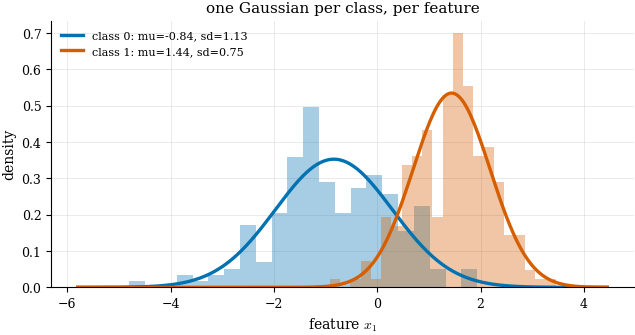

In [2]:
def gauss_pdf(x, mu, sd):
    "the 1-D normal density"
    return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))

# two classes, two features
covs = np.stack([np.diag([1.3, 0.5]), np.diag([0.6, 1.4])])
X, y, _ = make_gaussian_classes(n=400, seed=3, mus=((-1.0, 0.3), (1.4, -0.4)), covs=covs)

# fit feature 0 of each class: a mean and a variance -- that is the whole fit
fig, ax = plt.subplots(figsize=(6.4, 3.4))
grid = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
for k, c in ((0, C0), (1, C1)):
    xk = X[y == k, 0]
    mu, sd = xk.mean(), xk.std()                      # np.std default ddof=0 = the MLE
    ax.hist(xk, bins=22, density=True, alpha=0.35, color=c)
    ax.plot(grid, gauss_pdf(grid, mu, sd), color=c, lw=2.4, label=f"class {k}: mu={mu:.2f}, sd={sd:.2f}")
ax.set_xlabel("feature $x_1$"); ax.set_ylabel("density"); ax.legend(fontsize=8)
ax.set_title("one Gaussian per class, per feature")
plt.show()

## 2. The "naive" assumption: multiply the features

With two features we need $p(x_1,x_2\mid y{=}k)$. Naive Bayes assumes the features are **independent
given the class**, so the joint is simply the product:

$$p(\mathbf{x}\mid y{=}k)=\prod_{j} \mathcal{N}(x_j;\mu_{kj},\sigma^2_{kj}).$$

Multiplying independent bells gives an **axis-aligned** ellipse &mdash; it can stretch along either
axis, but it can never *tilt*.

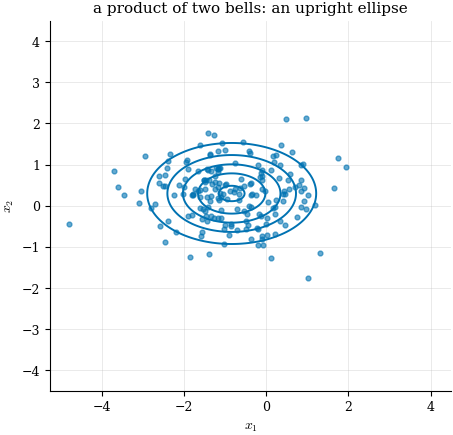

Naive Bayes can stretch the ellipse along each axis, but never tilt it.


In [3]:
def nb_density(P, mu, sd):
    "product of per-feature Gaussians, evaluated on a stack of points P"
    return np.prod(gauss_pdf(P, mu, sd), axis=1)

mu0, sd0 = X[y == 0].mean(axis=0), X[y == 0].std(axis=0)
gx, gy = np.meshgrid(np.linspace(-4.5, 4.5, 260), np.linspace(-4.5, 4.5, 260))
G = np.column_stack([gx.ravel(), gy.ravel()])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=12, color=C0, alpha=0.6)
ax.contour(gx, gy, nb_density(G, mu0, sd0).reshape(gx.shape), levels=5, colors=C0, linewidths=1.4)
ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("a product of two bells: an upright ellipse")
plt.show()
print("Naive Bayes can stretch the ellipse along each axis, but never tilt it.")

## 3. The classifier, from scratch

Now assemble the recipe. Two practical points:

* we add up **logs** instead of multiplying densities &mdash; a product of many small numbers underflows
  to zero, and $\log$ never changes which class is biggest;
* scikit-learn adds a tiny constant to every variance (`var_smoothing`) so a nearly-constant feature
  cannot blow up. We reproduce it exactly, so our numbers match theirs.

In [4]:
class GaussianNBScratch:
    "Gaussian naive Bayes: a prior, plus a mean and a variance per feature per class."

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.epsilon_ = self.var_smoothing * X.var(axis=0).max()
        self.prior_ = np.array([(y == k).mean() for k in self.classes_])
        self.theta_ = np.array([X[y == k].mean(axis=0) for k in self.classes_])
        self.var_ = np.array([X[y == k].var(axis=0) for k in self.classes_]) + self.epsilon_
        return self

    def log_joint(self, X):
        "log(prior) + sum_j log N(x_j) -- one column per class"
        const = np.log(self.prior_) - 0.5 * np.sum(np.log(2 * np.pi * self.var_), axis=1)
        quad = -0.5 * np.sum((X[:, None, :] - self.theta_) ** 2 / self.var_, axis=2)
        return const + quad

    def predict_proba(self, X):
        L = self.log_joint(X)
        L = L - L.max(axis=1, keepdims=True)          # subtract the max, then normalize
        e = np.exp(L)
        return e / e.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.log_joint(X).argmax(axis=1)]

ours = GaussianNBScratch().fit(X, y)
print("class priors :", ours.prior_.round(3))
print("means (theta):\n", ours.theta_.round(3))
print("variances    :\n", ours.var_.round(3))
print(f"\ntraining accuracy: {(ours.predict(X) == y).mean():.3f}")

class priors : [0.478 0.522]
means (theta):
 [[-0.84   0.297]
 [ 1.438 -0.455]]
variances    :
 [[1.281 0.458]
 [0.557 1.446]]

training accuracy: 0.902


In [5]:
from sklearn.naive_bayes import GaussianNB
sk = GaussianNB().fit(X, y)

print("means identical      :", np.array_equal(ours.theta_, sk.theta_))
print("variances identical  :", np.array_equal(ours.var_, sk.var_))
print("priors identical     :", np.allclose(ours.prior_, sk.class_prior_))
print("probabilities match  :", np.allclose(ours.predict_proba(X), sk.predict_proba(X)))
print("predictions match    :", np.array_equal(ours.predict(X), sk.predict(X)))

means identical      : True
variances identical  : True
priors identical     : True
probabilities match  : True
predictions match    : True


> &#11088; **Key idea.** There was no optimizer and no iteration &mdash; fitting a generative model is
> just **counting and averaging**. Everything above is means, variances and class frequencies.

## 4. The decision boundary

Shading shows $\mathbb{P}(y{=}1\mid\mathbf{x})$; the black line is where it crosses $0.5$, i.e. where
the two prior-weighted portraits **tie**. Notice the boundary is *curved*: the two classes have
different spreads, so the quadratic terms do not cancel.

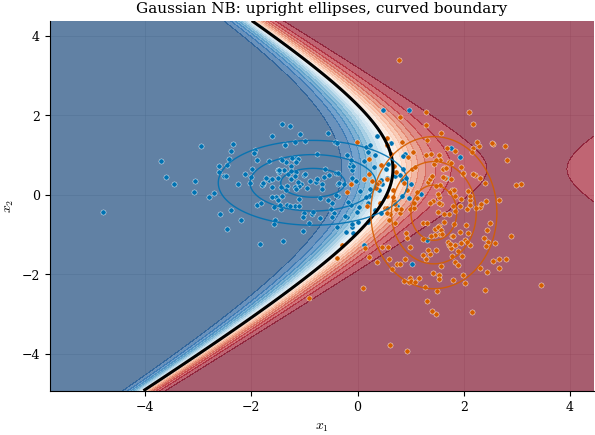

per-feature variances, class 0: [1.28 0.46]
per-feature variances, class 1: [0.56 1.45]
-> different spreads => a curved boundary. Equal spreads would give a straight line.


In [6]:
gx, gy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 320),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 320))
G = np.column_stack([gx.ravel(), gy.ravel()])
P1 = ours.predict_proba(G)[:, 1].reshape(gx.shape)

fig, ax = plt.subplots(figsize=(6.0, 4.4))
ax.contourf(gx, gy, P1, levels=20, cmap="RdBu_r", alpha=0.65)
ax.contour(gx, gy, P1, levels=[0.5], colors="black", linewidths=2.2)
for k, c in ((0, C0), (1, C1)):
    ax.scatter(X[y == k, 0], X[y == k, 1], s=14, color=c, edgecolor="white", linewidth=0.3)
    ax.contour(gx, gy, nb_density(G, ours.theta_[k], np.sqrt(ours.var_[k])).reshape(gx.shape),
               levels=3, colors=c, linewidths=1.0, alpha=0.9)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Gaussian NB: upright ellipses, curved boundary")
plt.show()

print("per-feature variances, class 0:", ours.var_[0].round(2))
print("per-feature variances, class 1:", ours.var_[1].round(2))
print("-> different spreads => a curved boundary. Equal spreads would give a straight line.")

## 5. On real data

The wine dataset: 178 samples, 13 continuous measurements, 3 grape cultivars. Exactly the setting
Gaussian naive Bayes was built for &mdash; and it needs no tuning at all.

In [7]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
Xtr, Xte, ytr, yte = train_test_split(wine.data, wine.target, test_size=0.4,
                                      random_state=0, stratify=wine.target)

mine = GaussianNBScratch().fit(Xtr, ytr)
theirs = GaussianNB().fit(Xtr, ytr)
print(f"test accuracy   ours {(mine.predict(Xte) == yte).mean():.3f} | "
      f"sklearn {theirs.score(Xte, yte):.3f}")
print("identical predictions:", np.array_equal(mine.predict(Xte), theirs.predict(Xte)))
print(f"\nparameters fitted: {mine.theta_.size} means + {mine.var_.size} variances "
      f"+ {mine.prior_.size} priors = {mine.theta_.size + mine.var_.size + mine.prior_.size}")

test accuracy   ours 0.972 | sklearn 0.972
identical predictions: True

parameters fitted: 39 means + 39 variances + 3 priors = 81


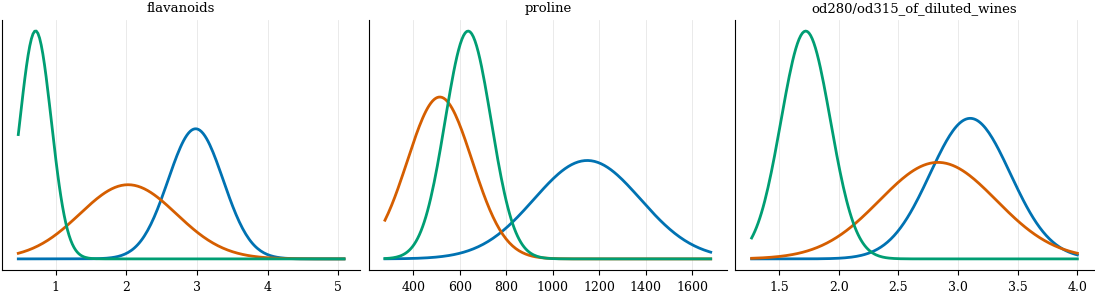

most separating features: flavanoids, proline, od280/od315_of_diluted_wines, alcohol, hue


In [8]:
# which features separate the cultivars best? compare the fitted class means
names = np.array(wine.feature_names)
spread = mine.theta_.std(axis=0) / np.sqrt(mine.var_.mean(axis=0))   # a crude separation score
order = np.argsort(spread)[::-1][:5]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.0))
for ax, j in zip(axes, order[:3]):
    g = np.linspace(Xtr[:, j].min(), Xtr[:, j].max(), 200)
    for k, c in ((0, C0), (1, C1), (2, "#009E73")):
        ax.plot(g, gauss_pdf(g, mine.theta_[k, j], np.sqrt(mine.var_[k, j])), color=c, lw=2)
    ax.set_title(names[j], fontsize=9.5); ax.set_yticks([])
plt.show()
print("most separating features:", ", ".join(names[order[:5]]))

## Recap & exercises

**Recap.**
* A **generative** classifier fits a small model per class, then compares
  $\pi_k\,p(\mathbf{x}\mid y{=}k)$ &mdash; the prior times the likelihood.
* For continuous features the per-class model is a **Gaussian**; naive Bayes assumes the features are
  independent within a class, so the density is a **product of 1-D Gaussians**.
* Fitting is **counting and averaging**: a class frequency, a mean and a variance per feature. No
  optimizer, no learning rate.
* We work in **log space** for numerical safety, which never changes the winner.
* Our from-scratch version reproduces scikit-learn's `GaussianNB` exactly &mdash; `var_smoothing`
  included &mdash; on both synthetic and real data.
* The independence assumption forces **upright ellipses**; the boundary still curves when the classes
  have different spreads.

**Exercises.**
1. Give both classes the same per-feature variances (edit `covs`) and re-plot the boundary. Does it
   become a straight line?
2. Add a third class to `make_gaussian_classes` and re-run. Does anything in `GaussianNBScratch` need
   to change?
3. Set `var_smoothing=0` and fit a feature that is constant within a class. What goes wrong, and why
   does scikit-learn add that constant?
4. On the wine data, drop the five most-separating features and refit. How much accuracy is lost?
5. Standardize the wine features before fitting. Does Gaussian naive Bayes care? Explain why.

*Next:* **05b &mdash; LDA and QDA**: drop the independence assumption, let each class have a full
covariance matrix, and watch the boundary become a tilted curve (or a straight line).